In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LOAD_EPOCH = 18

SAVE_FIGURES = True

model_name_to_show_label = {
    "causalsinh": r"Causal + $\sinh^{-1}$",
    "causal": "Causal",
    "vanillasinh": r"RevIN + $\sinh^{-1}$",
    "vanilla": "RevIN",
    "prefix4sinh": r"Prefix@4 + $\sinh^{-1}$",
    "prefix4": "Prefix@4", 

}

dic_model_colors = {
    r"Causal + $\sinh^{-1}$": "#573030FF",  # vivid orange
    r"Causal":                 "#FF7F00",  # semi-transparent brown
    r"RevIN + $\sinh^{-1}$":   "#00CC66",  # vivid green
    r"RevIN":                  "#0055FF",  # electric deep blue
    r"Prefix@4 + $\sinh^{-1}$": "#CC0099",  # strong magenta
    r"Prefix@4":               "#FF3300",  # bright red-orange

}

def load_npz(filepath):
    """Load npz file and return as dictionary"""
    return np.load(filepath)

models = ["causalsinh", "causal", "vanillasinh", "vanilla", "prefix4sinh", "prefix4", ]

context_lengths = [64, 128, 256, 512, 1024]

aggregated_skill_scores = {
    'mse': np.zeros((len(models), len(models))),
    'mae': np.zeros((len(models), len(models))),
    'mase': np.zeros((len(models), len(models))),
    'sql': np.zeros((len(models), len(models)))
}

skill_scores_mse_matrix = np.zeros((len(models), len(models)))
skill_scores_mae_matrix = np.zeros((len(models), len(models)))
skill_scores_mase_matrix = np.zeros((len(models), len(models)))
skill_scores_sql_matrix = np.zeros((len(models), len(models)))

for i, baseline in enumerate(models):
    for j, comparison in enumerate(models):
        mse_baseline = []
        mae_baseline = []
        mase_baseline = []
        sql_baseline = []
        mse_comparison = []
        mae_comparison = []
        mase_comparison = []
        sql_comparison = []
        
        for context in context_lengths:
            try:
                r_baseline = load_npz(f'results/{LOAD_EPOCH}/{baseline}/{context}.npz')
                r_comparison = load_npz(f'results/{LOAD_EPOCH}/{comparison}/{context}.npz')
                
                for k1, k2 in zip(r_baseline, r_comparison):
                    assert k1 == k2, "Predictions do not match"
                    metric = k1.split("_")[0].lower()
                    tar_size = int(k1.split("_")[1])
                    if metric == "rmse":
                        mse_baseline.extend(r_baseline[k1])
                        mse_comparison.extend(r_comparison[k2])
   
                    elif metric == "mae":
                        mae_baseline.extend(r_baseline[k1])
                        mae_comparison.extend(r_comparison[k2])
                    elif metric == "sql":
                        sql_baseline.extend(r_baseline[k1])
                        sql_comparison.extend(r_comparison[k2])
                    else:
                        mase_baseline.extend(r_baseline[k1])
                        mase_comparison.extend(r_comparison[k2])
                
            except FileNotFoundError:
                print(f"Warning: Files not found for {baseline} or {comparison}")
                continue
        
        if len(mse_baseline) > 0 and len(mse_comparison) > 0:
            scores_mse = []
            for p1, p2 in zip(mse_baseline, mse_comparison):
                scores_mse.append(p2/p1)
            scores_mse = np.array(scores_mse)
            scores_mse = np.clip(scores_mse, 0.01, 100)
            n = len(scores_mse)
            geometric_mean = np.exp(np.mean(np.log(scores_mse)))
            skill_scores_mse = 1 - geometric_mean
            skill_scores_mse_matrix[i, j] = skill_scores_mse
        
        # Calculate MAE skill score
        if len(mae_baseline) > 0 and len(mae_comparison) > 0:
            scores_mae = []
            for p1, p2 in zip(mae_baseline, mae_comparison):
                scores_mae.append(p2/p1)
            scores_mae = np.array(scores_mae)
            scores_mae = np.clip(scores_mae, 0.01, 100)
            n = len(scores_mae)
            geometric_mean = np.exp(np.mean(np.log(scores_mae)))
            skill_scores_mae = 1 - geometric_mean
            skill_scores_mae_matrix[i, j] = skill_scores_mae
        
        # Calculate MASE skill score
        if len(mase_baseline) > 0 and len(mase_comparison) > 0:
            scores_mase = []
            for p1, p2 in zip(mase_baseline, mase_comparison):
                scores_mase.append(p2/p1)
            scores_mase = np.array(scores_mase)
            scores_mase = np.clip(scores_mase, 0.01, 100)
            n = len(scores_mase)
            geometric_mean = np.exp(np.mean(np.log(scores_mase)))
            skill_scores_mase = 1 - geometric_mean
            skill_scores_mase_matrix[i, j] = skill_scores_mase
        
        # Calculate SQL skill score
        if len(sql_baseline) > 0 and len(sql_comparison) > 0:
            scores_sql = []
            for p1, p2 in zip(sql_baseline, sql_comparison):
                scores_sql.append(p2/p1)
            scores_sql = np.array(scores_sql)
            scores_sql = np.clip(scores_sql, 0.01, 100)
            n = len(scores_sql)
            geometric_mean = np.exp(np.mean(np.log(scores_sql)))
            skill_scores_sql = 1 - geometric_mean
            skill_scores_sql_matrix[i, j] = skill_scores_sql

        print(f"{baseline} vs {comparison} - RMSE: {skill_scores_mse_matrix[i,j]:.4f}, "
              f"MAE: {skill_scores_mae_matrix[i,j]:.4f}, MASE: {skill_scores_mase_matrix[i,j]:.4f}, SQL: {skill_scores_sql_matrix[i,j]:.4f}")

aggregated_skill_scores['mse'] = skill_scores_mse_matrix.T
aggregated_skill_scores['mae'] = skill_scores_mae_matrix.T
aggregated_skill_scores['mase'] = skill_scores_mase_matrix.T
aggregated_skill_scores['sql'] = skill_scores_sql_matrix.T

print("\n" + "="*50)
print("Aggregated skill scores across all context lengths")
print("="*50)

causalsinh vs causalsinh - RMSE: 0.0000, MAE: 0.0000, MASE: 0.0000, SQL: 0.0000
causalsinh vs causal - RMSE: -0.0035, MAE: -0.0051, MASE: -0.0061, SQL: -0.0091
causalsinh vs vanillasinh - RMSE: -0.0165, MAE: 0.0097, MASE: 0.0194, SQL: 0.0090
causalsinh vs vanilla - RMSE: -0.0094, MAE: 0.0119, MASE: 0.0276, SQL: 0.0169
causalsinh vs prefix4sinh - RMSE: 0.0554, MAE: 0.0978, MASE: 0.1231, SQL: 0.1156
causalsinh vs prefix4 - RMSE: 0.0447, MAE: 0.0856, MASE: 0.1075, SQL: 0.1011
causal vs causalsinh - RMSE: 0.0035, MAE: 0.0051, MASE: 0.0060, SQL: 0.0091
causal vs causal - RMSE: 0.0000, MAE: 0.0000, MASE: 0.0000, SQL: 0.0000
causal vs vanillasinh - RMSE: -0.0130, MAE: 0.0147, MASE: 0.0253, SQL: 0.0180
causal vs vanilla - RMSE: -0.0059, MAE: 0.0169, MASE: 0.0335, SQL: 0.0258
causal vs prefix4sinh - RMSE: 0.0587, MAE: 0.1024, MASE: 0.1284, SQL: 0.1236
causal vs prefix4 - RMSE: 0.0480, MAE: 0.0903, MASE: 0.1129, SQL: 0.1093
vanillasinh vs causalsinh - RMSE: 0.0163, MAE: -0.0098, MASE: -0.0198, S

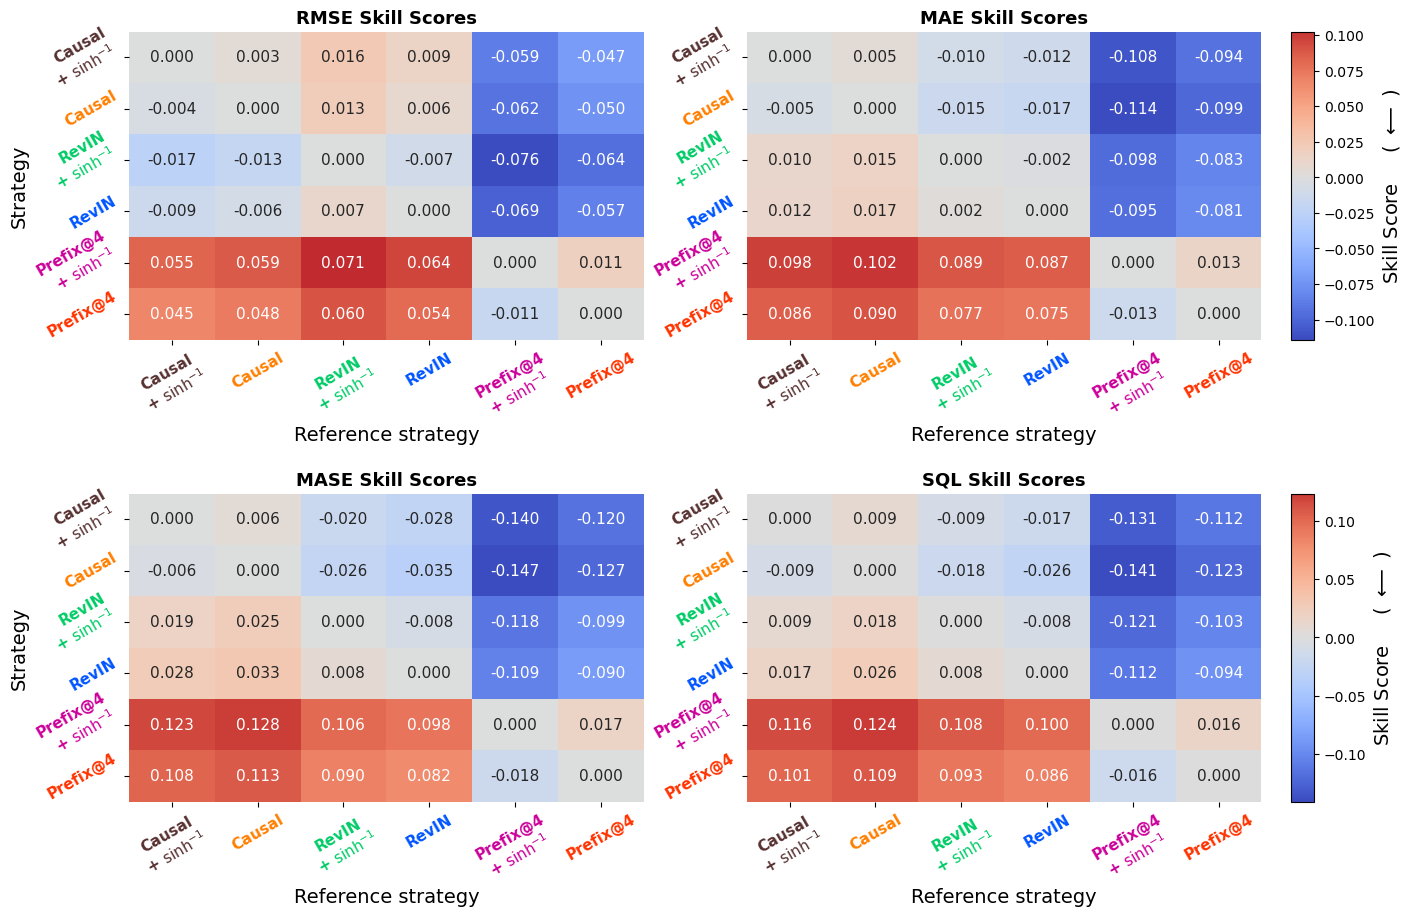

In [2]:
display_names = []
for m in models:
    label = model_name_to_show_label[m]
    if '+ $\sinh^{-1}$' in label:
        label = label.replace(' + $\sinh^{-1}$', '\n+ $\sinh^{-1}$')
    display_names.append(label)

metrics = [
    ('mse',  'RMSE Skill Scores'),
    ('mae',  'MAE Skill Scores'),
    ('mase', 'MASE Skill Scores'),
    ('sql',  'SQL Skill Scores'),
]

start=0
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
square = False

for idx, (metric, title) in enumerate(metrics):
    row, col = divmod(idx, 2)
    ax = axes[row, col]

    sns.heatmap(aggregated_skill_scores[metric][start:], annot=True, fmt='.3f', cmap='coolwarm',
                xticklabels=display_names, yticklabels=display_names[start:],
                center=0, ax=ax, cbar=False, 
                annot_kws={'fontsize': 11}, square=square)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Reference strategy', fontsize=14)
    ax.set_ylabel('Strategy' if col == 0 else '', fontsize=14)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=30)
    ax.tick_params(axis='both', labelsize=11)

    for label in ax.get_xticklabels():
        original_text = label.get_text().replace('\n', ' ')
        label.set_color(dic_model_colors[original_text])
        label.set_fontweight('bold')
    for label in ax.get_yticklabels():
        original_text = label.get_text().replace('\n', ' ')
        label.set_color(dic_model_colors[original_text])
        label.set_fontweight('bold')

fig.subplots_adjust(right=0.88, hspace=0.5)

# One colorbar per row, vertically centered on each row
for row in range(2):
    # Get the bounding boxes of the two axes in this row
    pos0 = axes[row, 0].get_position()
    pos1 = axes[row, 1].get_position()
    cbar_ax = fig.add_axes([0.90, pos0.y0, 0.015, pos0.y1 - pos0.y0])
    cbar = fig.colorbar(axes[row, 1].collections[0], cax=cbar_ax)
    cbar.set_label('Skill Score     ( $\longleftarrow$ )', fontsize=14)
    cbar.ax.tick_params(labelsize=10)

if SAVE_FIGURES:
    plt.savefig('figures/skill_scores_mid.pdf', format='pdf', dpi=300, bbox_inches='tight')